In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


# Load Saved Model

In [ ]:
model = BaselineCNN().to(device)
model.load_state_dict(torch.load("baseline_cnn_cifar10.pth", map_location=device))
model.eval()

print("Baseline CNN loaded successfully.")


# Load Test Dataset(clean)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


# Verify Clean Accuracy

In [ ]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

clean_acc = 100 * correct / total
print(f"Clean Test Accuracy (Baseline CNN): {clean_acc:.2f}%")


In [ ]:
import torch
import torch.nn as nn


# FGSM Attack

## The Fast Gradient Sign Method (FGSM) is an adversarial attack designed to fool machine learning models by adding a small, calculated perturbation to input data. It is a "white-box" attack, meaning it requires access to the model's gradients

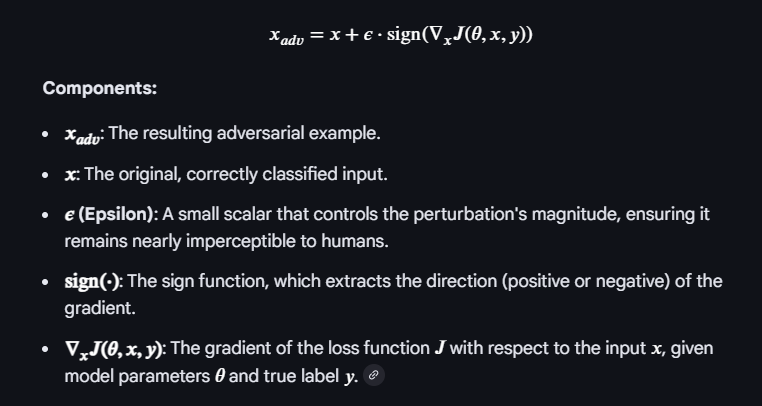

In [ ]:
def fgsm_attack(model, images, labels, epsilon):
    images.requires_grad = True

    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)

    model.zero_grad()
    loss.backward()

    # Collect gradient sign
    grad_sign = images.grad.sign()

    # Create adversarial example
    adv_images = images + epsilon * grad_sign

    # Clamp to valid range [-1, 1] because of normalization
    adv_images = torch.clamp(adv_images, -1, 1)

    return adv_images


# FGSM Evaluation Function

## This function:
   ### Applies FGSM to each batch
   ### Measures adversarial accuracy

In [ ]:
def evaluate_fgsm(model, dataloader, epsilon):
    correct = 0
    total = 0

    model.eval()

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        adv_images = fgsm_attack(model, images, labels, epsilon)

        outputs = model(adv_images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    return acc


# Run FGSM for Different ε Values

In [ ]:
epsilons = [0.01, 0.03, 0.05,0.07]

for eps in epsilons:
    acc = evaluate_fgsm(model, test_loader, eps)
    print(f"FGSM Accuracy at ε={eps}: {acc:.2f}%")


# Visualize Clean vs FGSM Image

In [ ]:
import matplotlib.pyplot as plt

data_iter = iter(test_loader)
images, labels = next(data_iter)
images, labels = images.to(device), labels.to(device)

adv_images = fgsm_attack(model, images, labels, epsilon=0.05)

# Pick one image
idx = 0

def unnormalize(img):
    img = img * 0.5 + 0.5
    return img.permute(1, 2, 0).cpu().detach()

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(unnormalize(images[idx]))
plt.title("Clean Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(unnormalize(adv_images[idx]))
plt.title("FGSM Image (ε=0.0)")
plt.axis("off")

plt.show()


# PGD Attack
## Projected Gradient Descent (PGD) is a powerful iterative adversarial attack used to test the robustness of machine learning models. It is essentially a multi-step version of the Fast Gradient Sign Method (FGSM) that includes a random starting point and a projection step to keep the perturbation within a defined boundary.
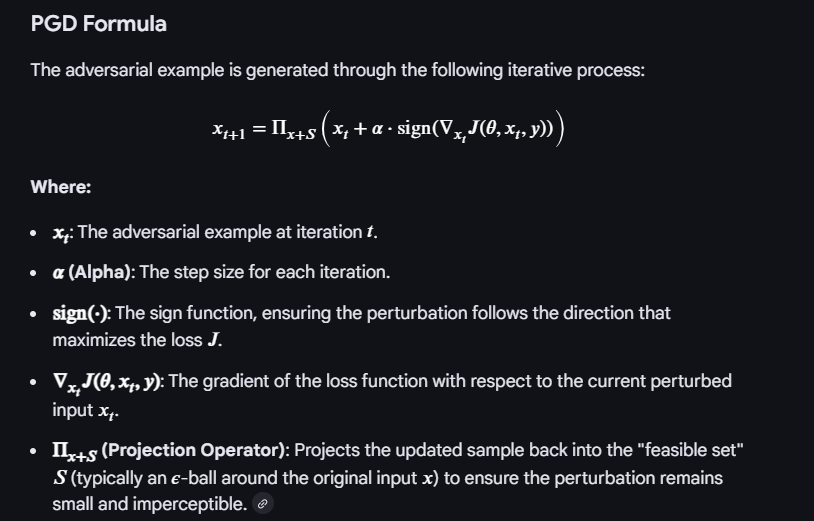

In [ ]:
def pgd_attack(model, images, labels, epsilon, alpha, iters):
    ori_images = images.clone().detach()

    images = images.clone().detach()
    images.requires_grad = True

    for _ in range(iters):
        outputs = model(images)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        model.zero_grad()
        loss.backward()

        # Gradient sign
        grad_sign = images.grad.sign()

        # Update adversarial image
        images = images + alpha * grad_sign

        # Projection (L-infinity constraint)
        eta = torch.clamp(images - ori_images, min=-epsilon, max=epsilon)
        images = torch.clamp(ori_images + eta, -1, 1).detach()
        images.requires_grad = True

    return images


# PGD Evaluation Function

In [ ]:
def evaluate_pgd(model, dataloader, epsilon, alpha, iters):
    correct = 0
    total = 0

    model.eval()

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        adv_images = pgd_attack(
            model=model,
            images=images,
            labels=labels,
            epsilon=epsilon,
            alpha=alpha,
            iters=iters
        )

        outputs = model(adv_images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    return acc


# Run PGD for Different ε Values

In [ ]:
epsilons = [0.01, 0.03, 0.05,0.07]
iters = 7   # standard
for eps in epsilons:
    alpha = eps / iters
    acc = evaluate_pgd(model, test_loader, eps, alpha, iters)
    print(f"PGD Accuracy at ε={eps}: {acc:.2f}%")


# Visualize PGD Adversarial Example

In [ ]:
data_iter = iter(test_loader)
images, labels = next(data_iter)
images, labels = images.to(device), labels.to(device)

adv_images = pgd_attack(
    model, images, labels,
    epsilon=0.03,
    alpha=0.03/7,
    iters=7
)

idx = 0

def unnormalize(img):
    return (img * 0.5 + 0.5).permute(1, 2, 0).cpu().detach()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(unnormalize(images[idx]))
plt.title("Clean Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(unnormalize(adv_images[idx]))
plt.title("PGD Image (ε=0.03)")
plt.axis("off")

plt.show()


# Comparative Analysis (Clean vs FGSM vs PGD)

In [ ]:
import matplotlib.pyplot as plt

# Get one batch
data_iter = iter(test_loader)
images, labels = next(data_iter)
images, labels = images.to(device), labels.to(device)

# Generate adversarial samples
fgsm_images = fgsm_attack(model, images, labels, epsilon=0.03)
pgd_images = pgd_attack(
    model, images, labels,
    epsilon=0.03,
    alpha=0.03/7,
    iters=7
)

def unnormalize(img):
    return (img * 0.5 + 0.5).permute(1, 2, 0).cpu().detach()

idx = 0  # visualize one image

plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.imshow(unnormalize(images[idx]))
plt.title("Clean Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(unnormalize(fgsm_images[idx]))
plt.title("FGSM (ε=0.03)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(unnormalize(pgd_images[idx]))
plt.title("PGD (ε=0.03)")
plt.axis("off")

plt.tight_layout()
plt.show()


# Accuracy vs Epsilon

## What it shows
## How accuracy collapses as ε increases
## FGSM vs PGD comparison
## Clear vulnerability proof

In [ ]:
import matplotlib.pyplot as plt

epsilons = [0.01, 0.03, 0.05]

fgsm_acc = [43.15, 17.40, 11.62]
pgd_acc  = [40.06, 9.40, 2.78]   # use your exact PGD values

plt.figure(figsize=(8,5))
plt.plot(epsilons, fgsm_acc, marker='o', label="FGSM")
plt.plot(epsilons, pgd_acc, marker='s', label="PGD")

plt.xlabel("Epsilon (ε)")
plt.ylabel("Accuracy (%)")
plt.title("Baseline CNN Accuracy vs Adversarial Strength")
plt.legend()
plt.grid(True)
plt.show()


# Clean vs FGSM vs PGD (Bar Chart)

## What it show
## Direct comparison at ε = 0.03
## Makes PGD dominance very clear

In [ ]:
labels = ["Clean", "FGSM (ε=0.03)", "PGD (ε=0.03)"]
accuracy = [74.9, 17.40, 9.40]  # replace PGD with exact value

plt.figure(figsize=(7,5))
plt.bar(labels, accuracy)
plt.ylabel("Accuracy (%)")
plt.title("Baseline CNN Performance Under Adversarial Attacks")
plt.grid(axis="y")
plt.show()


# Accuracy Drop %

## What it shows
## Relative degradation


In [ ]:
clean_acc = 74.9
attack_acc = [43.15, 17.40, 11.62]

drop = [clean_acc - a for a in attack_acc]

plt.figure(figsize=(7,5))
plt.bar(["FGSM 0.01", "FGSM 0.03", "FGSM 0.05"], drop)
plt.ylabel("Accuracy Drop (%)")
plt.title("Accuracy Degradation due to FGSM Attack")
plt.grid(axis="y")
plt.show()


# DeepFool Attack Analysis

## DeepFool is an iterative adversarial attack that finds the minimum perturbation required to change a model’s prediction.
## Unlike FGSM or PGD:
## It does not fix ε beforehand
## It asks:
## 👉 “What is the smallest change needed to cross the decision boundary?”

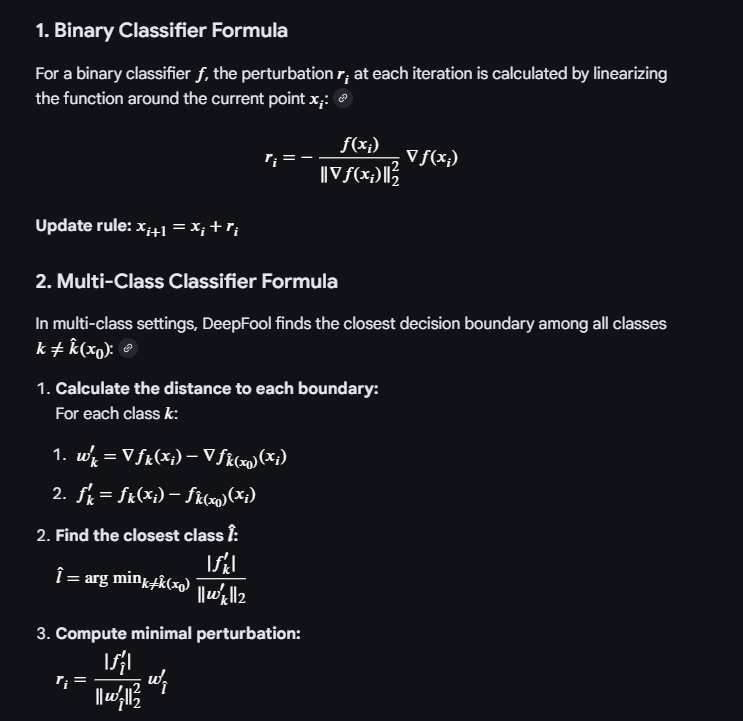

In [ ]:
import torch
import torch.nn as nn


# DeepFool Attack Function

In [ ]:
def deepfool_attack(model, image, label, num_classes=10, overshoot=0.02, max_iter=50):
    model.eval()

    image = image.clone().detach().to(device)
    perturbed_image = image.clone().detach().requires_grad_(True)

    r_tot = torch.zeros_like(image)

    for _ in range(max_iter):
        outputs = model(perturbed_image)
        logits = outputs[0]

        pred = torch.argmax(logits)
        if pred.item() != label.item():
            break

        # Gradient of the true class
        grad_orig = torch.autograd.grad(
            logits[label], perturbed_image, retain_graph=True
        )[0]

        min_pert = float('inf')
        w = None

        for k in range(num_classes):
            if k == label:
                continue

            grad_k = torch.autograd.grad(
                logits[k], perturbed_image, retain_graph=True
            )[0]

            w_k = grad_k - grad_orig
            f_k = logits[k] - logits[label]

            pert_k = torch.abs(f_k) / (torch.norm(w_k.flatten()) + 1e-8)

            if pert_k < min_pert:
                min_pert = pert_k
                w = w_k

        # Compute minimal perturbation
        r_i = (min_pert + 1e-4) * w / (torch.norm(w.flatten()) + 1e-8)
        r_tot = r_tot + r_i

        # 🔑 VERY IMPORTANT: recreate leaf tensor
        perturbed_image = (
            image + (1 + overshoot) * r_tot
        ).clamp(-1, 1).detach().clone().requires_grad_(True)

    return perturbed_image.detach()


# Evaluate DeepFool on Test Dataset

In [ ]:
def evaluate_deepfool(model, dataloader, max_samples=200):
    model.eval()
    fooled = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        for i in range(images.size(0)):
            img = images[i:i+1]
            lbl = labels[i]

            adv_img = deepfool_attack(model, img, lbl)

            pred = torch.argmax(model(adv_img), dim=1)
            if pred.item() != lbl.item():
                fooled += 1

            total += 1
            if total >= max_samples:
                break
        if total >= max_samples:
            break

    return 100 * fooled / total


# Run DeepFool Evaluation

In [ ]:
fooling_rate = evaluate_deepfool(model, test_loader, max_samples=200)
print(f"DeepFool Fooling Rate: {fooling_rate:.2f}%")


# Carlini & Wagner (C&W) Attack

## The Carlini & Wagner (C&W) attack is an optimization-based adversarial attack that explicitly minimizes perturbation size while forcing misclassification.
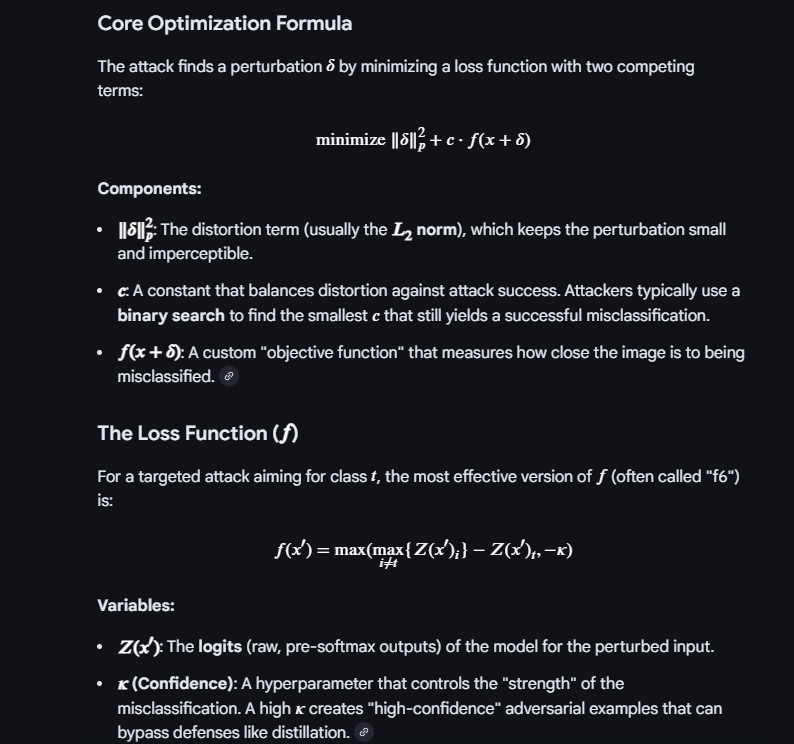

In [ ]:
# Wrap Your PyTorch Model for Foolbox

import foolbox as fb
import torch
import numpy as np

# Foolbox model wrapper
fmodel = fb.PyTorchModel(
    model,
    bounds=(-1, 1),   # IMPORTANT: matches CIFAR-10 normalization
    device=device
)



# Prepare Test Samples

In [ ]:
x_test, y_test = [], []

for images, labels in test_loader:
    x_test.append(images)
    y_test.append(labels)
    if len(x_test) * images.size(0) >= 200:
        break

x_test = torch.cat(x_test, dim=0)[:200].to(device)
y_test = torch.cat(y_test, dim=0)[:200].to(device)


# Run Carlini & Wagner (L2) Attack

In [ ]:
attack = fb.attacks.L2CarliniWagnerAttack(
    binary_search_steps=5,
    steps=100,
    stepsize=0.01,
    confidence=0.0
)

raw_adv, clipped_adv, success = attack(
    fmodel,
    x_test,
    y_test,
    epsilons=[1.0]   # REQUIRED by Foolbox API
)



# Compute Fooling Rate

In [ ]:
cw_fooling_rate = success.float().mean().item() * 100
print(f"C&W (L2) Fooling Rate: {cw_fooling_rate:.2f}%")


# FINAL ATTACK RESULTS (MASTER TABLE)

In [ ]:
import pandas as pd

final_results = {
    "Attack": [
        "Clean",
        "FGSM (ε=0.01)", "FGSM (ε=0.03)", "FGSM (ε=0.05)", "FGSM (ε=0.07)",
        "PGD (ε=0.01)", "PGD (ε=0.03)", "PGD (ε=0.05)", "PGD (ε=0.07)",
        "DeepFool",
        "C&W (L2)"
    ],
    "Accuracy (%)": [
        74.90,
        43.15, 17.40, 11.62, 8.36,
        40.06, 9.40, 2.78, 1.02,
        0.00,     # DeepFool = 100% fooling
        7.00      # C&W = 93% fooling → 7% accuracy
    ]
}

df_final = pd.DataFrame(final_results)
df_final


In [ ]:
# Clean vs All Attacks (Accuracy Drop)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df_final["Attack"], df_final["Accuracy (%)"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Baseline CNN Accuracy under Various Adversarial Attacks")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


In [ ]:
# FGSM vs PGD vs Strong Attacks

attack_names = [
    "Clean",
    "FGSM (0.03)",
    "PGD (0.03)",
    "C&W",
    "DeepFool"
]

accuracy_values = [
    74.90,
    17.40,
    9.40,
    7.00,
    0.00
]

plt.figure(figsize=(8,5))
plt.bar(attack_names, accuracy_values)
plt.ylabel("Accuracy (%)")
plt.title("Comparison of CNN Robustness Across Attack Types")
plt.grid(axis="y")
plt.show()
